In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

The formula for Shannon entropy $H(x)$ of a categorically distributed random variable $x$ is given as $$ H(x) = -\sum_{i=1}^{k} p_i \log_2 p_i $$

Using NumPy's powerful broadcasting capability we can implement this formula as follows:

In [2]:
def shannon_entropy(probabilities):
    return -np.sum(probabilities * np.log2(probabilities))

### Eight coin flips ###

Since entropy of two independent events (i.e. two coin flips) $H(X \cdot Y)$ is equal to the sum of entropies of the two events, $H(X) + H(Y)$, we can decompose the eight flips into eight times the entropy of a single flip. Formally, this is a vital step since the formula for Shannon entropy given above only holds for _categorically distributed_ random variables. Repeated coin throws are instead distributed according to _binomial distribution_ (and dice throws according to _multinomial distribution_), for which the entropy formula becomes a bit more complicated.

In [3]:
num_flips = 8
odds = [0.5, 0.5]
entropy = num_flips * shannon_entropy(odds)
print(f"Entropy for 8 coin flips is {entropy:.3f} bits")

Entropy for 8 coin flips is 8.000 bits


If the coin isn't entirely fair and tails are twice as likely as heads, we get the following result:

In [10]:
num_flips = 8
p = 0.333
odds = [p, 1 - p]
entropy = num_flips * shannon_entropy(odds)
print(f"Entropy for 8 flips of a weighted coin is {entropy:.3f}bits ")

Entropy for 8 flips of a weighted coin is 7.344bits 


Graphically, the entropy value for any coin bias looks like this:

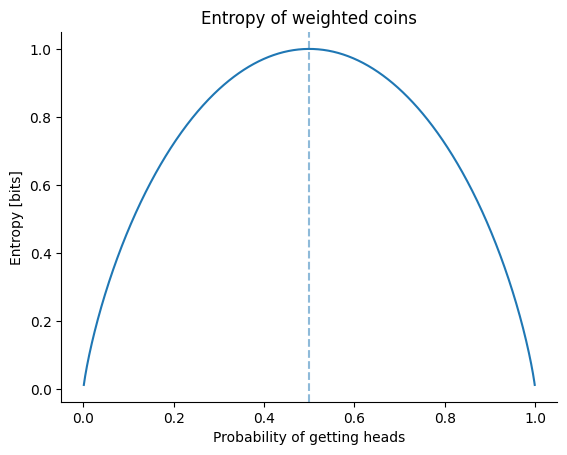

In [9]:
p = np.linspace(0, 1, 1000, endpoint=False)[1:, None]
odds = np.concat((p, 1-p), axis=1)
entropy = np.apply_along_axis(shannon_entropy, 1, odds)

fig, ax = plt.subplots()
ax.plot(p, entropy)
ax.axvline(0.5, ls="--", zorder=1.9, alpha=0.5)

ax.set_title("Entropy of weighted coins")
ax.set_xlabel("Probability of getting heads")
ax.set_ylabel("Entropy [bits]")
ax.spines[['top', 'right']].set_visible(False)

plt.show()

### Six-sided die ###

We can similarly look at a classic six-sided die...

In [ ]:
num_sides = 6
num_rolls = 5
probabilities = [1/num_sides] * num_sides
entropy = num_rolls * shannon_entropy(probabilities)
print(f"Entropy for 5 rolls of a six-sided die: {entropy:.6f}")

Entropy for 5 rolls of a six-sided die: 12.924813


### Fair eight-sided die ###

...as well as eight-sided die.

In [ ]:
num_sides = 8
probabilities = [1 / num_sides] * num_sides
entropy = shannon_entropy(probabilities)
print(f"Entropy for a roll of a fair eight-sided die: {entropy:.3f} bits")

Entropy for a roll of a fair eight-sided die: 3.000 bits


### Weighted eight-sided die ###

What if the die isn't fair either? Let's take a look:

In [ ]:
weighted_probabilities = [1/2, 1/4, 1/8, 1/16, 1/64, 1/64, 1/64, 1/64]
weighted_entropy = shannon_entropy(weighted_probabilities)
print(f"Entropy for a rolls of a weighted eight-sided die: {weighted_entropy:.3f} bits")

Entropy for a rolls of a weighted eight-sided die: 2.000 bits


We see again that more likely events carry less information, i.e. their entropy is lower.

Finally we can investigate the link between _information_ and _entropy_. Suppose you throw a die and you want to share the outcome with your friend. How many bits of information does it take to do that?

In case of a fair die the answer is obvious, it's three. That's how many bits it takes to index eight numbers in binary to number each face of the die.

Can we do better for a weighted die though?

In [ ]:
num_throws = 1000
weighted_die_throws = rng.multinomial(n=num_throws, pvals=weighted_probabilities)
encodings = ["1", "01", "001", "0001", "000011", "000010", "000001", "000000"]

codelengths = [len(e) for e in encodings]
avg_length = np.sum(weighted_die_throws * codelengths) / num_throws
print(f"Average length of transmitted result is {avg_length:3f} bits")

Average length of transmitted result is 2.073000 bits


Turns out that we can. Some of you may have also noticed, that the number of bits encoding each result $x \sim p(x)$ is equal to the _entropy_ of the result, $-log(x)$. This is indeed the optimal codelength and the reason why "entropy is the lowest amount of information capable of representing reality".